In [3]:
import json
import os

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import time
from typing import Dict, List
from urllib import response


import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as show
import requests
import torch
from requests import Response
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler

import requests
import pandas as pd
import time
import os
from preprocessing.feature_creating import GroupByScaler
from models.models import EIIE,EI3,GPM,TransformerPM
from models.hyper_net import HyperNetPortfolioRL
from agents.dlr_agent import DRLAgent
from environments.portfolio_env import PortfolioOptimizationEnv
from prediction.predict_future_distribution import PortfolioPredictor
from  datetime import datetime
from utils.utils import process_folder_data


# загрузка данных с moex

In [4]:



def download_moex_candles(sec_ids, interval=60, limit=500, save_path='./data/', delay=0.01):
    """
    Загружает исторические данные свечей с MOEX для списка тикеров и сохраняет их в CSV.

    Параметры:
    sec_ids (list): Список тикеров.
    interval (int): Интервал свечей в минутах (по умолчанию 60).
    limit (int): Количество свечей за один запрос (по умолчанию 500).
    save_path (str): Директория для сохранения файлов (по умолчанию './data/').
    delay (float): Задержка между запросами в секундах (по умолчанию 0.01).
    """
    os.makedirs(save_path, exist_ok=True)

    for sec_id in sec_ids:
        url = f'https://iss.moex.com/iss/engines/stock/markets/shares/securities/{sec_id}/candles.json'
        params = {
            'start': '0',
            'interval': str(interval),
            'limit': str(limit),
        }
        print(f'START {sec_id}')
        start_time = time.time()
        df = pd.DataFrame()

        while True:
            try:
                response = requests.get(url=url, params=params)
                if response.status_code != 200:
                    print(f'Ошибка {response.status_code} для {sec_id}')
                    break
                data = response.json()
                if 'candles' not in data or not data['candles']['data']:
                    break
                temp_df = pd.DataFrame(data['candles']['data'], columns=data['candles']['columns'])
                df = pd.concat([df, temp_df])
                params['start'] = str(int(params['start']) + int(params['limit']))
                time.sleep(delay)
            except requests.exceptions.RequestException as e:
                print(f'Сетевая ошибка при загрузке {sec_id}: {e}')
                break
            except Exception as e:
                print(f'Ошибка при обработке данных {sec_id}: {e}')
                break

        if not df.empty:
            df['ticker'] = sec_id
            file_path = os.path.join(save_path, f'{sec_id}.csv')
            df.to_csv(file_path, index=False, encoding='UTF-8')
            end_time = time.time()
            print(f'Time spent = {round(end_time - start_time, 2)} s')
            print(f'File size = {os.stat(file_path).st_size} bytes')
        else:
            print(f'Нет данных для {sec_id}')

        print(f'END {sec_id}')


# Пример использования
# sec_ids = [
#     'ABIO', 'AFKS', 'AFLT', 'AKRN', 'AMEZ', 'APTK', 'BLNG', 'BSPB', 'CHMF', 'CHMK',
#     'ELFV', 'FEES', 'FESH', 'GAZP', 'GCHE', 'HYDR', 'INGR', 'IRAO', 'IRKT', 'KMAZ',
#     'LKOH', 'LNZLP', 'LNZL', 'LSRG', 'MAGN', 'MGNT', 'MRKC', 'MRKK', 'MRKP', 'MRKU',
#     'MRKV', 'MRKY', 'MRKZ', 'MSNG', 'MSRS', 'MTLR', 'MTSS', 'MVID', 'NKNCP', 'NKNC',
#     'NLMK', 'NMTP', 'NVTK', 'OGKB', 'PIKK', 'PLZL', 'RASP', 'ROSN', 'RTKMP', 'RTKM',
#     'SBERP', 'SBER', 'SNGSP', 'SNGS', 'SVAV', 'TATNP', 'TATN', 'TGKA', 'TGKB', 'TRMK',
#     'TRNFP', 'VSMO', 'VTBR'
# ]

# download_moex_candles(sec_ids)

# Ковертим с freq H на D

In [5]:


def process_daily_data(input_folder, output_folder):
    """
    Обрабатывает CSV-файлы из указанной входной папки, преобразует данные в дневные интервалы
    и сохраняет результаты в выходную папку.
    
    Параметры:
    input_folder (str): Путь к папке с исходными CSV-файлами
    output_folder (str): Путь к папке для сохранения обработанных данных
    """
    # Создаем выходную папку, если она не существует
    os.makedirs(output_folder, exist_ok=True)
    
    # Обрабатываем каждый CSV-файл во входной папке
    for file in os.listdir(input_folder):
        if file.endswith(".csv"):
            # Читаем файл
            df = pd.read_csv(os.path.join(input_folder, file))
            
            # Преобразуем колонку 'begin' в datetime
            df['begin'] = pd.to_datetime(df['begin'])
            
            # Создаем колонку с датой (без времени)
            df['date'] = df['begin'].dt.date
            
            # Группируем по дате и агрегируем данные
            daily = df.groupby('date').agg({
                'open': 'first',
                'close': 'last',
                'high': 'max',
                'low': 'min',
                'value': 'sum',
                'volume': 'sum',
                'ticker': 'first'
            }).reset_index()
            
            # Сохраняем результат
            output_path = os.path.join(output_folder, file)
            daily.to_csv(output_path, index=False, encoding='utf-8')

# Пример использования
# process_daily_data("data", "data_daily")

# фильтруем данные отбираем по количеству пропусков 

In [6]:


# Вызов функции
result = process_folder_data(
    folder_path="../data",
    date_col='date',
    start_date='2010-01-01',
    threshold=0.03
)


print(result.head())
# Вызов функции

             close    high     low    open   volume   close    high     low  \
tic           ABIO    ABIO    ABIO    ABIO     ABIO    AFKS    AFKS    AFKS   
datetime                                                                      
2011-11-17  11.600  11.779  11.383  11.406  20200.0  23.500  23.699  22.900   
2011-11-18  11.605  11.848  11.237  11.237  89500.0  22.923  23.289  22.880   
2011-11-21  11.167  11.675  11.050  11.675  53700.0  21.750  22.870  21.700   
2011-11-22  10.965  11.267  10.700  11.101  81200.0  21.902  22.298  21.889   
2011-11-23  10.770  11.099  10.640  10.774  85000.0  23.750  23.750  21.902   

              open     volume  ...   close    high     low    open  volume  \
tic           AFKS       AFKS  ...    VSMO    VSMO    VSMO    VSMO    VSMO   
datetime                       ...                                           
2011-11-17  23.699  2000800.0  ...  5010.0  5049.9  4550.0  4799.8  8884.0   
2011-11-18  23.121  1176700.0  ...  4903.8  5010.0  483

In [7]:

X=result.fillna(method='ffill')
df_stacked_X_train=X.stack(level='tic')
df_flat_X_train = df_stacked_X_train.reset_index()

df_flat_X_train

C:\Users\bodya\AppData\Local\Temp\ipykernel_2680\1116901583.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X=result.fillna(method='ffill')
C:\Users\bodya\AppData\Local\Temp\ipykernel_2680\1116901583.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_stacked_X_train=X.stack(level='tic')


,datetime,tic,close,high,low,open,volume
0,2011-11-17,ABIO,11.600000,11.779000,11.383000,11.406000,20200.0
1,2011-11-17,AFKS,23.500000,23.699000,22.900000,23.699000,2000800.0
2,2011-11-17,AFLT,51.000000,51.520000,50.500000,51.500000,883800.0
3,2011-11-17,AKRN,1410.000000,1430.000000,1351.000000,1410.000000,70290.0
4,2011-11-17,AMEZ,9.280000,9.779000,9.120000,9.501000,96200.0
...,...,...,...,...,...,...,...
206236,2025-04-18,TGKB,0.006695,0.006725,0.006595,0.006625,112000000.0
206237,2025-04-18,TRMK,108.100000,108.980000,107.400000,108.960000,558350.0
206238,2025-04-18,TRNFP,1291.800000,1303.400000,1283.000000,1302.000000,320883.0
206239,2025-04-18,VSMO,31740.000000,31920.000000,31640.000000,31800.000000,177.0


In [8]:
df_flat_X_train['datetime']=pd.to_datetime(df_flat_X_train['datetime'])
df_flat_X_train.groupby("tic").count()

,datetime,close,high,low,open,volume
tic,,,,,,
ABIO,3381,3381,3381,3381,3381,3381
AFKS,3381,3381,3381,3381,3381,3381
AFLT,3381,3381,3381,3381,3381,3381
AKRN,3381,3381,3381,3381,3381,3381
AMEZ,3381,3381,3381,3381,3381,3381
...,...,...,...,...,...,...
TGKB,3381,3381,3381,3381,3381,3381
TRMK,3381,3381,3381,3381,3381,3381
TRNFP,3381,3381,3381,3381,3381,3381


# чекаем на факт консолидации 

In [9]:


df_flat_X_train['prev_close'] = df_flat_X_train.groupby('tic')['close'].shift(1)
df_flat_X_train['close_jump'] = df_flat_X_train['close'] / df_flat_X_train['prev_close']

df_flat_X_train['prev_open'] = df_flat_X_train.groupby('tic')['open'].shift(1)
df_flat_X_train['open_jump'] = df_flat_X_train['open'] / df_flat_X_train['prev_open']
# Считаем, что обратный сплит — если цена выросла более чем в 2 раза за 1 день
reverse_splits_close = df_flat_X_train[df_flat_X_train['close_jump'] > 2]
reverse_splits_open = df_flat_X_train[df_flat_X_train['open_jump'] > 2]
print("Возможные обратные сплиты close:")
print(reverse_splits_close[['datetime', 'tic', 'prev_close', 'close', 'close_jump']])
print("Возможные обратные сплиты open:")
print(reverse_splits_open[['datetime', 'tic', 'prev_open', 'open', 'open_jump']])
df_flat_X_train.drop(columns=['prev_close', 'prev_open'], inplace=True)
df_flat_X_train.drop(columns=['close_jump', 'open_jump'], inplace=True)


Возможные обратные сплиты close:
        datetime   tic  prev_close    close  close_jump
47459 2014-12-18  AFKS      6.6300  13.6000    2.051282
48632 2015-01-20  IRAO      0.0071   0.7615  107.253521
Возможные обратные сплиты open:
        datetime   tic  prev_open   open   open_jump
47520 2014-12-19  AFKS   7.300000  14.75    2.020548
48632 2015-01-20  IRAO   0.006749   0.80  118.536079


# скейлим данные 

In [10]:

valid_columns = ['open', 'high', 'low', 'close', 'volume','tic'] 
gbsclr=GroupByScaler(by="tic", scaler=MaxAbsScaler)
portfolio_norm_df = gbsclr.fit_transform(df_flat_X_train[valid_columns])
portfolio_norm_df['date']=df_flat_X_train['datetime']

# сплитуем данные 

In [11]:
df_portfolio = portfolio_norm_df[["date", "tic", "close", "high", "low","volume", "open"]]

df_portfolio_train = df_portfolio[(df_portfolio["date"] < "2022-07-01")]
df_portfolio_test = df_portfolio[(df_portfolio["date"] >= "2022-07-01") ]


In [12]:
df_portfolio_train

,date,tic,close,high,low,volume,open
0,2011-11-17,ABIO,0.077858,0.066548,0.079601,0.000628,0.075025
1,2011-11-17,AFKS,0.488576,0.483653,0.481598,0.003037,0.490703
2,2011-11-17,AFLT,0.226667,0.228978,0.232987,0.005598,0.236618
3,2011-11-17,AKRN,0.052203,0.048148,0.060023,0.325986,0.049648
4,2011-11-17,AMEZ,0.049716,0.048040,0.049297,0.000923,0.046674
...,...,...,...,...,...,...,...
162011,2022-06-30,TGKB,0.241334,0.230303,0.228887,0.007684,0.248816
162012,2022-06-30,TRMK,0.205609,0.212440,0.206050,0.014978,0.211678
162013,2022-06-30,TRNFP,0.517100,0.543487,0.530214,0.000199,0.541991
162014,2022-06-30,VSMO,0.906250,0.914913,0.929470,0.019705,0.933590


In [13]:
TIME_WINDOW=32

INITIAL_FEATURES=5 # Равен колличеству OHLCV
EPOCH=7
BATCH_SIZE=128 # Размер батча и размер памяти PVM
LR=0.0004
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [14]:
environment = PortfolioOptimizationEnv(
        df_portfolio_train,
        initial_amount=1000000,
        comission_fee_pct=0.0025,
        time_window=TIME_WINDOW,
        reward_scaling=0.1,
        #return_last_action=True,
        features=["close", "high", "low","volume","open"],
        normalize_df=None
    )

environment_test = PortfolioOptimizationEnv(
    df_portfolio_test,
    initial_amount=1000000,
    comission_fee_pct=0.0025,
    reward_scaling=0.01,
    time_window=TIME_WINDOW,
    features=["close", "high", "low","volume","open"],
    normalize_df=None,
    #return_last_action=True
)




In [15]:
import gc
gc.collect()  # запуск сборщика мусора Python
torch.cuda.empty_cache()  # очистка кэша CUDA

In [11]:
# Для CPU
torch.manual_seed(42)

# Для GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True  # Для воспроизводимости
    torch.backends.cudnn.benchmark = False     # Отключает автотюнинг (может помочь)

# EIIE

In [9]:
K_SIZE=4
CONV_MID_FEATURES=2
CONV_FINAL_FEATURES=20
POLICY=EIIE

In [10]:
# set PolicyGradient parameters
model_kwargs = {
    "lr": LR,
    "policy": POLICY,
    #'validation_env':environment_test,
    'batch_size':BATCH_SIZE
}

# here, we can set EIIE's parameters
policy_kwargs = {
    "k_size": K_SIZE,
    "conv_mid_features":CONV_MID_FEATURES,
    "conv_final_features":CONV_FINAL_FEATURES,
    "initial_features":INITIAL_FEATURES,
    "time_window": TIME_WINDOW,
    'device':DEVICE
}

model = DRLAgent(environment).get_model("pg", DEVICE, model_kwargs, policy_kwargs)

In [11]:
training_model=DRLAgent.train_model(model, episodes=EPOCH,)


  0%|          | 0/7 [00:00<?, ?it/s]

Initial portfolio value:1000000
Final portfolio value: 5656951.0
Final accumulative portfolio value: 5.656951
Maximum DrawDown: -0.4338654274897198
Sortino ratio: 1.702826496937697
Sharpe ratio: 0.4487943814592161


 14%|█▍        | 1/7 [02:11<13:09, 131.51s/it]

Initial portfolio value:1000000
Final portfolio value: 6415012.0
Final accumulative portfolio value: 6.415012
Maximum DrawDown: -0.43095504993144496
Sortino ratio: 1.864068362042022
Sharpe ratio: 0.44814029747395734


 29%|██▊       | 2/7 [04:24<11:01, 132.23s/it]

...

 71%|███████▏  | 5/7 [10:55<04:22, 131.26s/it]

Initial portfolio value:1000000
Final portfolio value: 49586600.0
Final accumulative portfolio value: 49.5866
Maximum DrawDown: -0.41805495141164706
Sortino ratio: 6.478045129702789
Sharpe ratio: 0.398979842036367


 86%|████████▌ | 6/7 [13:06<02:10, 130.95s/it]

Initial portfolio value:1000000
Final portfolio value: 97391536.0
Final accumulative portfolio value: 97.391536
Maximum DrawDown: -0.45301651101794527
Sortino ratio: 11.215908701889449
Sharpe ratio: 0.3651701373988071


100%|██████████| 7/7 [15:15<00:00, 130.81s/it]


In [15]:

hyperparameters = {
    'time_window': TIME_WINDOW,
    'initial_features': INITIAL_FEATURES,
    'k_size': K_SIZE,
    'conv_mid_features': CONV_MID_FEATURES,
    'conv_final_features': CONV_FINAL_FEATURES,
    'device': DEVICE
}


checkpoint = {
    'model_state_dict': model.train_policy.state_dict(),
    'hyperparameters': hyperparameters,
    'training_info': {
        'policy': POLICY.__name__,
        'epoch': EPOCH,
        'batch_size': BATCH_SIZE,
        'lr': LR,
        'timestamp': datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    }
}


torch.save(checkpoint, f"../saved_models/model_checkpoint_{POLICY.__name__}_batch_{BATCH_SIZE}_window_{TIME_WINDOW}_epoch_{EPOCH}_{LR}.pt")

In [ ]:
#torch.save(model.train_policy.state_dict(), f"policy_EIIE_batch_{BATCH_SIZE}_window_{TIME_WINDOW}_epoch_{EPOCH}.pt")

In [14]:
environment_test = PortfolioOptimizationEnv(
    df_portfolio_test,
    initial_amount=1000000,
    comission_fee_pct=0.0025,
    reward_scaling=0.01,
    time_window=TIME_WINDOW,
    features=["close", "high", "low","volume","open"],
    normalize_df=None,
    
)


#policy = EIIE(time_window=TIME_WINDOW, device=DEVICE,initial_features=INITIAL_FEATURES,k_size=K_SIZE)
#policy.load_state_dict(torch.load(f"../saved_models/model_checkpoint_EIIE_batch_{BATCH_SIZE}_window_{TIME_WINDOW}_epoch_{EPOCH}_{LR}.pt")['model_state_dict'])
#policy.load_state_dict(torch.load(f"../saved_models/policy_EIIE_batch_512_window_16_epoch_5_BEST.pt"))
# test
DRLAgent.DRL_validation(model,online_training_period=100, test_env=environment_test,learning_rate=LR)



Initial portfolio value:1000000
Final portfolio value: 1826912.125
Final accumulative portfolio value: 1.826912125
Maximum DrawDown: -0.38740323128014564
Sortino ratio: 1.7345892181052693
Sharpe ratio: 1.1732196437475158


# Моделирование реального прогноза на некст стейт

In [14]:
# Пример использования:




# Инициализация предиктора
predictor = PortfolioPredictor(
    model_path=f"../saved_models/model_checkpoint_{POLICY.__name__}_batch_{BATCH_SIZE}_window_{TIME_WINDOW}_epoch_{EPOCH}_{LR}.pt",
    model_type="EIIE",
    device='cpu'
)

# Прогнозирование весов на будущее
future_weights = predictor.predict_future_weights(
    df=df_portfolio_test,
    initial_amount=1000000,
    time_window=16,
    num_steps=1 # Прогноз на 30 дней вперед
)

#print(future_weights.head())

# Бэктестирование
last_action_final, results_df, model_train = predictor.backtest(
    df=df_portfolio_test,
    initial_amount=1000000,
    time_window=16
)



##print(backtest_results.head()) 

Normalizing ['close', 'high', 'low', 'volume', 'open'] by previous time...
2022-07-22 00:00:00


c:\Users\bodya\Desktop\pfm\prediction\predict_future_distribution.py:308: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obs = torch.tensor(obs, device=self.device).float()
c:\Users\bodya\Desktop\pfm\prediction\predict_future_distribution.py:309: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  last_actions = torch.tensor(last_actions, device=self.device).float()
c:\Users\bodya\Desktop\pfm\prediction\predict_future_distribution.py:310: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  price_variations = torch.tensor(price_variations, device=self.

Initial portfolio value:1000000
Final portfolio value: 1733706.875
Final accumulative portfolio value: 1.733706875
Maximum DrawDown: -0.39515076462180865
Sortino ratio: 1.517711820199314
Sharpe ratio: 1.0311192915306844


c:\Users\bodya\Desktop\pfm\prediction\predict_future_distribution.py:308: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obs = torch.tensor(obs, device=self.device).float()
c:\Users\bodya\Desktop\pfm\prediction\predict_future_distribution.py:309: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  last_actions = torch.tensor(last_actions, device=self.device).float()
c:\Users\bodya\Desktop\pfm\prediction\predict_future_distribution.py:310: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  price_variations = torch.tensor(price_variations, device=self.

In [ ]:
def predict_weights(model, observation, last_action):
        """Прогнозирует веса портфеля на основе текущего наблюдения.
        
        Аргументы:
            observation: Наблюдение из среды.
            last_action: Последнее действие (распределение портфеля).
            
        Возвращает:
            Прогнозируемые веса портфеля.
        """
        # Переводим в батч, если не батч
        if isinstance(observation, np.ndarray) and len(observation.shape) == 3:
            obs_batch = np.expand_dims(observation, axis=0)
        else:
            obs_batch = observation
            
        if isinstance(last_action, np.ndarray) and len(last_action.shape) == 1:
            last_action_batch = np.expand_dims(last_action, axis=0)
        else:
            last_action_batch = last_action
        
        # Получаем прогноз от модели
        with torch.no_grad():
            predicted_weights =model(obs_batch, last_action_batch)
        return predicted_weights

In [32]:
environment_test = PortfolioOptimizationEnv(
    df_portfolio_test,
    initial_amount=1000000,
    comission_fee_pct=0.0025,
    reward_scaling=0.1,
    time_window=TIME_WINDOW,
    features=["close", "high", "low","volume","open"],
    normalize_df=None,
    return_last_action=True
)




checkpoint = torch.load(f"../saved_models/model_checkpoint_{POLICY.__name__}_batch_{BATCH_SIZE}_window_{TIME_WINDOW}_epoch_{EPOCH}_{LR}.pt")
hyperparameters=checkpoint['hyperparameters']

policy = EIIE(**hyperparameters)

policy.load_state_dict(checkpoint['model_state_dict'])
# Получение параметров


#policy.load_state_dict(torch.load(f"../saved_models/policy_EIIE_batch_512_window_16_epoch_5_BEST.pt"))

done = False
        
# Прогоняем модель через всю историю
   # Получаем начальное состояние


if environment_test._new_gym_api:
    observation, info = environment_test.reset()
else:
    observation = environment_test.reset()
    
done = False

# Прогоняем модель через всю историю
while not done:
    # Если наблюдение - словарь
    if isinstance(observation, dict):
        state = observation['state']
        last_action = observation['last_action']
    else:
        state = observation
        last_action = environment_test._actions_memory[-1]
        
    # Получаем прогноз весов
    predicted_weights = predict_weights(policy,state, last_action)
    
    # Делаем шаг в среде
    observation, reward, done, *_ = environment_test.step(predicted_weights)

C:\Users\bodya\AppData\Local\Temp\ipykernel_14748\2384219506.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f"../saved_models/model_checkpoint_

Initial portfolio value:1000000
Final portfolio value: 1751080.25
Final accumulative portfolio value: 1.75108025
Maximum DrawDown: -0.39271258815056687
Sortino ratio: 1.3797536649398578
Sharpe ratio: 0.9689015757769625


# EI3

In [37]:
K_SHORT=4
K_MEDIUM=min(21, TIME_WINDOW - 1)
CONV_MID_FEATURES=3
CONV_FINAL_FEATURES=20
POLICY=EI3


In [ ]:
# set PolicyGradient parameters
model_kwargs = {
    "lr": LR,
    "policy":POLICY,
    #'validation_env':environment_test,
    'batch_size':BATCH_SIZE
}



  

policy_kwargs = {
    "k_short": K_SHORT,
    "conv_mid_features": CONV_MID_FEATURES,
    "conv_final_features": CONV_FINAL_FEATURES,
    "initial_features": INITIAL_FEATURES,
    "time_window": TIME_WINDOW,
    "k_medium":  K_MEDIUM
}

model = DRLAgent(environment).get_model("pg", DEVICE, model_kwargs, policy_kwargs)

In [22]:
training_model=DRLAgent.train_model(model, episodes=EPOCH,)


  0%|          | 0/5 [00:00<?, ?it/s]

Initial portfolio value:1000000
Final portfolio value: 6177379.5
Final accumulative portfolio value: 6.1773795
Maximum DrawDown: -0.43652649616635897
Sortino ratio: 1.7795606851873051
Sharpe ratio: 0.45887432976658116


 20%|██        | 1/5 [02:57<11:50, 177.63s/it]

Initial portfolio value:1000000
Final portfolio value: 10304066.0
Final accumulative portfolio value: 10.304066
Maximum DrawDown: -0.4212561170311855
Sortino ratio: 2.3844038120067137
Sharpe ratio: 0.4784894628405663


 40%|████      | 2/5 [05:57<08:57, 179.04s/it]

...

 60%|██████    | 3/5 [08:54<05:55, 177.88s/it]

Initial portfolio value:1000000
Final portfolio value: 71382712.0
Final accumulative portfolio value: 71.382712
Maximum DrawDown: -0.4174262104516334
Sortino ratio: 7.685040627391026
Sharpe ratio: 0.40981948044841865


 80%|████████  | 4/5 [11:48<02:56, 176.67s/it]

Initial portfolio value:1000000
Final portfolio value: 124385040.0
Final accumulative portfolio value: 124.38504
Maximum DrawDown: -0.4650751824486713
Sortino ratio: 12.673274369125622
Sharpe ratio: 0.3622182578005794


100%|██████████| 5/5 [14:41<00:00, 176.39s/it]


In [19]:
model.train_policy

TransformerPM(
  (input_projection): Linear(in_features=5, out_features=128, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (temporal_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, 

In [39]:

hyperparameters = {
    'TIME_WINDOW': TIME_WINDOW,
    'INITIAL_FEATURES': INITIAL_FEATURES,

   
    'K_SHORT': K_SHORT,
    'K_MEDIUM': K_MEDIUM,
    'CONV_MID_FEATURES': CONV_MID_FEATURES,
    'CONV_FINAL_FEATURES': CONV_FINAL_FEATURES,
    'DEVICE': DEVICE
}


checkpoint = {
    'model_state_dict': model.train_policy.state_dict(),
    'hyperparameters': hyperparameters,
    'training_info': {
        'policy': POLICY.__name__,
        'epoch': EPOCH,
        'batch_size': BATCH_SIZE,
        'lr': LR,
        'timestamp': datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    }
}


torch.save(checkpoint, f"../saved_models/model_checkpoint_{POLICY.__name__}_batch_{BATCH_SIZE}_window_{TIME_WINDOW}_epoch_{EPOCH}_{LR}.pt")

In [24]:
environment_test = PortfolioOptimizationEnv(
    df_portfolio_test,
    initial_amount=1000000,
    comission_fee_pct=0.0025,
    reward_scaling=0.1,
    time_window=TIME_WINDOW,
    features=["close", "high", "low","volume","open"],
    normalize_df=None,
    
)


DRLAgent.DRL_validation(model, test_env=environment_test,learning_rate=0.01)



Initial portfolio value:1000000
Final portfolio value: 1821175.875
Final accumulative portfolio value: 1.821175875
Maximum DrawDown: -0.409705574094992
Sortino ratio: 1.5920844158087684
Sharpe ratio: 1.0706624302786671


# Transformer 

In [18]:
D_MODEL = 16
NHEAD = 4
NUM_ENCODER_LAYERS = 3
DIM_FEEDFORWARD = 64
DROPOUT = 0.0

POLICY=TransformerPM


In [19]:
# set PolicyGradient parameters
model_kwargs = {
    "lr": LR,
    "policy":POLICY,
    #'validation_env':environment_test,
    'batch_size':BATCH_SIZE
}



  
policy_kwargs = {
    "initial_features": INITIAL_FEATURES,
    "d_model": D_MODEL,
    "nhead": NHEAD,
    "num_encoder_layers": NUM_ENCODER_LAYERS,
    "dim_feedforward": DIM_FEEDFORWARD,
    "dropout": DROPOUT,
    "time_window": TIME_WINDOW,
    "device": DEVICE,
}

model = DRLAgent(environment).get_model("pg", DEVICE, model_kwargs, policy_kwargs)

In [20]:
training_model=DRLAgent.train_model(model, episodes=3,)

  0%|          | 0/3 [00:00<?, ?it/s]

Initial portfolio value:1000000
Final portfolio value: 6180009.0
Final accumulative portfolio value: 6.180009
Maximum DrawDown: -0.4347375692431633
Sortino ratio: 1.7707933866375123
Sharpe ratio: 0.4648321994951055


 33%|███▎      | 1/3 [02:39<05:18, 159.37s/it]

Initial portfolio value:1000000
Final portfolio value: 6179861.0
Final accumulative portfolio value: 6.179861
Maximum DrawDown: -0.4347573174909576
Sortino ratio: 1.7707835136432934
Sharpe ratio: 0.46484207662421234


 67%|██████▋   | 2/3 [05:21<02:40, 160.85s/it]

Initial portfolio value:1000000
Final portfolio value: 6183168.0
Final accumulative portfolio value: 6.183168
Maximum DrawDown: -0.4347147841339847
Sortino ratio: 1.7718857802997614
Sharpe ratio: 0.4646987867839529


100%|██████████| 3/3 [08:02<00:00, 160.75s/it]


In [16]:

DRLAgent.DRL_validation(model,online_training_period=100, test_env=environment_test,learning_rate=0.1)

Initial portfolio value:1000000
Final portfolio value: 1513202.5
Final accumulative portfolio value: 1.5132025
Maximum DrawDown: -0.38908755519582383
Sortino ratio: 1.0808778341005885
Sharpe ratio: 0.786111174712266


# HyperNetPortfolioRL

In [15]:
TIME_WINDOW=32
environment = PortfolioOptimizationEnv(
    df_portfolio_train,
    initial_amount=1000000,
    comission_fee_pct=0.0025,
    reward_scaling=0.1,
    time_window=TIME_WINDOW,
    features=["close", "high", "low","volume","open"],
    normalize_df=None,
    
)
# set PolicyGradient parameters
model_kwargs = {
    "lr": LR,
    "policy":HyperNetPortfolioRL,
    #'validation_env':environment_test,
    'batch_size':256
}



  
policy_kwargs = {
    "initial_features": 5,
    "time_window": TIME_WINDOW,
    "embed_dim": 64,
    "attention_heads": 4,
    "graph_features": 32,
    "recurrent_features": 32,
    "dropout": 0.1,
    "num_assets": None,  # Будет определено во время forward pass
    "device": "cuda:0",
    "time_scales": [2, 8, 16]
}

model = DRLAgent(environment).get_model("pg", DEVICE, model_kwargs, policy_kwargs)

In [22]:
training_model=DRLAgent.train_model(model, episodes=5,)

  0%|          | 0/5 [00:00<?, ?it/s]

Initial portfolio value:1000000
Final portfolio value: 6375421.5
Final accumulative portfolio value: 6.3754215
Maximum DrawDown: -0.44898394038664735
Sortino ratio: 1.8425450124860114
Sharpe ratio: 0.4567096899706534


 20%|██        | 1/5 [04:46<19:05, 286.27s/it]

Initial portfolio value:1000000
Final portfolio value: 10543590.0
Final accumulative portfolio value: 10.54359
Maximum DrawDown: -0.45748223664214616
Sortino ratio: 2.925690060450782
Sharpe ratio: 0.4004719366549695


 40%|████      | 2/5 [09:34<14:22, 287.66s/it]

...

 60%|██████    | 3/5 [14:17<09:30, 285.26s/it]

Initial portfolio value:1000000
Final portfolio value: 17173954.0
Final accumulative portfolio value: 17.173954
Maximum DrawDown: -0.4856497839562175
Sortino ratio: 4.647775265056412
Sharpe ratio: 0.3647224377201595


 80%|████████  | 4/5 [18:53<04:41, 281.67s/it]

Initial portfolio value:1000000
Final portfolio value: 23762800.0
Final accumulative portfolio value: 23.7628
Maximum DrawDown: -0.502188552334092
Sortino ratio: 6.1687137792453965
Sharpe ratio: 0.35248315238992284


100%|██████████| 5/5 [23:20<00:00, 280.12s/it]


In [26]:
environment_test = PortfolioOptimizationEnv(
    df_portfolio_test,
    initial_amount=1000000,
    comission_fee_pct=0.0025,
    reward_scaling=1,
    time_window=32,
    features=["close", "high", "low","volume","open"],
    normalize_df=None,
    
)


DRLAgent.DRL_validation(model,online_training_period=10000000, test_env=environment_test,learning_rate=0.001)



Initial portfolio value:1000000
Final portfolio value: 1378777.625
Final accumulative portfolio value: 1.378777625
Maximum DrawDown: -0.45134427337623484
Sortino ratio: 0.8824399660102414
Sharpe ratio: 0.629355976778987


# hyper_pg

In [16]:
TIME_WINDOW=32
environment = PortfolioOptimizationEnv(
    df_portfolio_train,
    initial_amount=1000000,
    comission_fee_pct=0.0025,
    reward_scaling=0.1,
    time_window=TIME_WINDOW,
    features=["close", "high", "low","volume","open"],
    normalize_df=None,
    
)

model_kwargs = {
    "lr": LR,
    "policy":HyperNetPortfolioRL,
    #'validation_env':environment_test,
    'batch_size':256
}



  
policy_kwargs = {
    "initial_features": 5,
    "time_window": TIME_WINDOW,
    "embed_dim": 64,
    "attention_heads": 4,
    "graph_features": 32,
    "recurrent_features": 32,
    "dropout": 0.1,
    "num_assets": None,  # Будет определено во время forward pass
    "device": "cuda:0",
    "time_scales": [2, 8, 16]
}

model = DRLAgent(environment).get_model("hyper_pg", DEVICE, model_kwargs, policy_kwargs)

c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:116: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler() if self.mixed_precision and torch.cuda.is_available() else None


In [17]:
training_model=DRLAgent.train_model(model, episodes=5,)

Training:   0%|          | 0/5 [00:00<?, ?it/s]c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` 

Initial portfolio value:1000000
Final portfolio value: 6441070.0
Final accumulative portfolio value: 6.44107
Maximum DrawDown: -0.44846264000958
Sortino ratio: 1.9193642361211438
Sharpe ratio: 0.4395493305164083


c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training:  20%|██        | 1/5 [04:33<18:14, 273.67s/it]c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(a

Initial portfolio value:1000000
Final portfolio value: 6603724.0
Final accumulative portfolio value: 6.603724
Maximum DrawDown: -0.4473375078766303
Sortino ratio: 1.931021135484808
Sharpe ratio: 0.44463133186170967


c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training:  40%|████      | 2/5 [09:08<13:43, 274.52s/it]c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(a

...

c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training:  60%|██████    | 3/5 [13:47<09:13, 276.58s/it]c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(a

Initial portfolio value:1000000
Final portfolio value: 5300108.5
Final accumulative portfolio value: 5.3001085
Maximum DrawDown: -0.448839663230557
Sortino ratio: 1.656918051466782
Sharpe ratio: 0.4427478457230181


c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training:  80%|████████  | 4/5 [18:21<04:35, 275.51s/it]c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(a

Initial portfolio value:1000000
Final portfolio value: 4896868.0
Final accumulative portfolio value: 4.896868
Maximum DrawDown: -0.44936630467301475
Sortino ratio: 1.5537065835706358
Sharpe ratio: 0.44400295271029894


c:\Users\bodya\Desktop\pfm\agents\hyper_policy.py:342: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training: 100%|██████████| 5/5 [22:53<00:00, 274.63s/it]


In [18]:
environment_test = PortfolioOptimizationEnv(
    df_portfolio_test,
    initial_amount=1000000,
    comission_fee_pct=0.0025,
    reward_scaling=1,
    time_window=32,
    features=["close", "high", "low","volume","open"],
    normalize_df=None,
    
)


DRLAgent.DRL_validation(model,online_training_period=10000000, test_env=environment_test,learning_rate=0.001)



AttributeError: 'HyperNetPolicyGradient' object has no attribute 'test_policy'

# Пост аналитика 

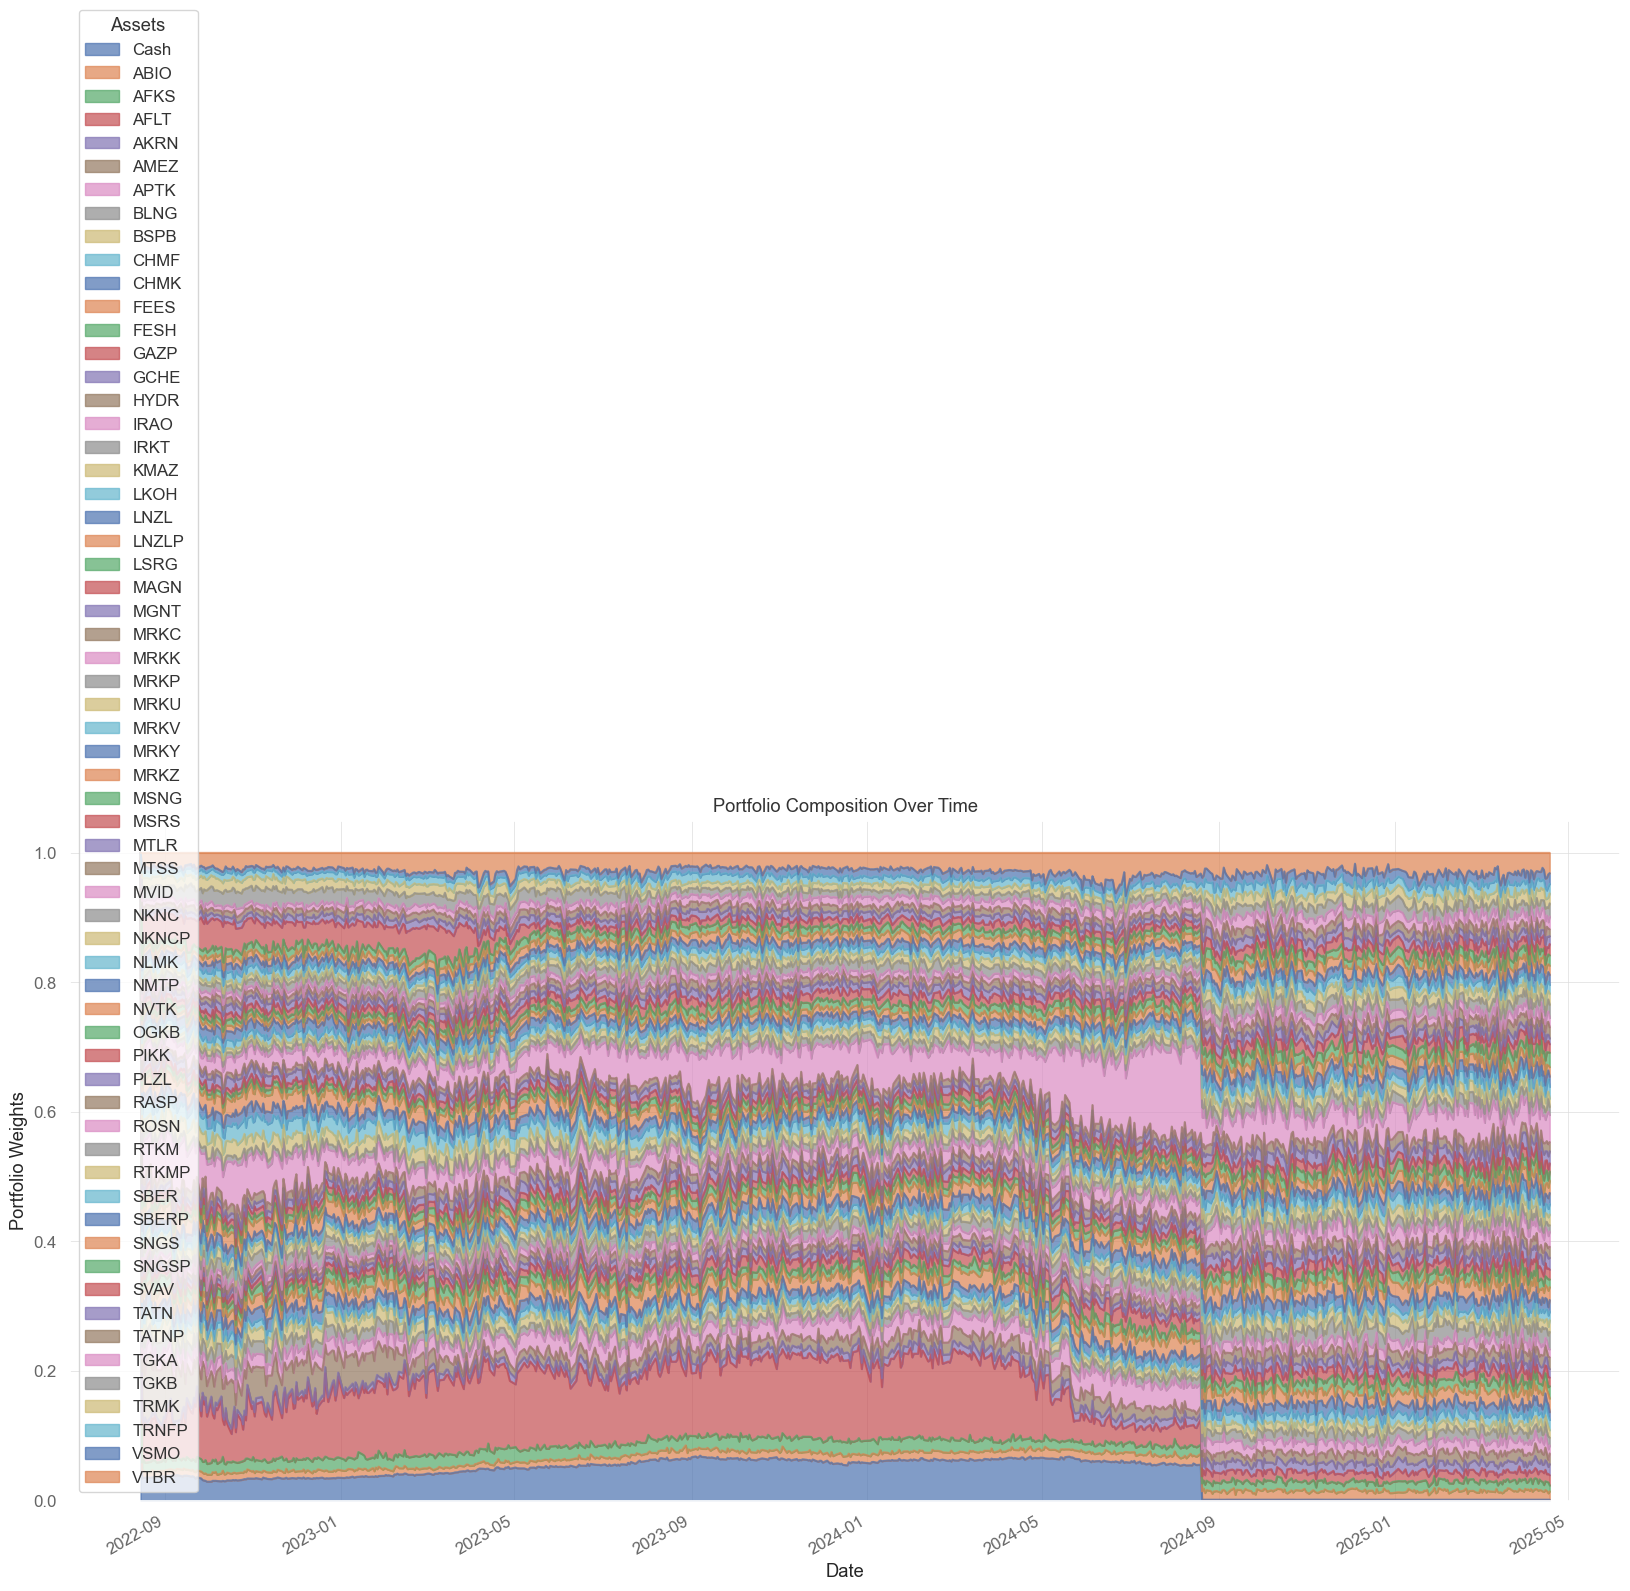

In [25]:
actions_memory = environment_test._actions_memory  

actions_df = pd.DataFrame(actions_memory, columns=["Cash"] + list(environment._tic_list))

# Добавление дат
actions_df["Date"] = environment_test._date_memory
actions_df.set_index("Date", inplace=True)

# Построение графика областей
actions_df.plot(kind="area", stacked=True, figsize=(20, 10), alpha=0.7)

# Настройка графика
plt.title("Portfolio Composition Over Time")
plt.ylabel("Portfolio Weights")
plt.xlabel("Date")
plt.legend(title="Assets")
plt.show()

## Дискретизация акций распределение ==> количетво акций на покупку

In [22]:
# 
# Получаем цены на каждую дату для каждой акции
prices = df_flat_X_train.pivot(index='datetime', columns='tic', values='close')

# Предполагаем, что сумма портфеля постоянна (например, 100000)
portfolio_value = 100000

# Берём только акции (без Cash)
stock_columns = [col for col in actions_df.columns if col != "Cash"]

# Для каждой даты и каждой акции считаем количество купленных акций
shares = (actions_df[stock_columns] * portfolio_value) / prices[stock_columns]
shares = shares.fillna(0)
shares_discrete = np.floor(shares)


print(shares_discrete.head())


            ABIO  AFKS  AFLT  AKRN  AMEZ  APTK  BLNG  BSPB  CHMF  CHMK  ...  \
2011-11-17   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
2011-11-18   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
2011-11-21   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
2011-11-22   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
2011-11-23   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   

            SNGSP  SVAV  TATN  TATNP  TGKA  TGKB  TRMK  TRNFP  VSMO  VTBR  
2011-11-17    0.0   0.0   0.0    0.0   0.0   0.0   0.0    0.0   0.0   0.0  
2011-11-18    0.0   0.0   0.0    0.0   0.0   0.0   0.0    0.0   0.0   0.0  
2011-11-21    0.0   0.0   0.0    0.0   0.0   0.0   0.0    0.0   0.0   0.0  
2011-11-22    0.0   0.0   0.0    0.0   0.0   0.0   0.0    0.0   0.0   0.0  
2011-11-23    0.0   0.0   0.0    0.0   0.0   0.0   0.0    0.0   0.0   0.0  

[5 rows x 61 columns]


In [16]:
prices

tic,ABIO,AFKS,AFLT,AKRN,AMEZ,APTK,BLNG,BSPB,CHMF,CHMK,...,SNGSP,SVAV,TATN,TATNP,TGKA,TGKB,TRMK,TRNFP,VSMO,VTBR
datetime,,,,,,,,,,,,,,,,,,,,,
2011-11-17,11.600,23.500,51.00,1410.0,9.280,48.990,11.650,93.88,428.2,3521.0,...,16.299,354.3,157.05,97.21,0.010397,0.003609,90.50,474.70,5010.0,345.40
2011-11-18,11.605,22.923,50.74,1374.1,9.006,48.980,11.456,89.00,426.1,3492.0,...,16.330,356.0,154.14,95.01,0.010272,0.003560,88.18,463.58,4903.8,340.00
2011-11-21,11.167,21.750,50.00,1395.0,8.809,47.490,10.980,82.99,395.5,3336.0,...,15.770,334.2,143.70,93.00,0.009991,0.003410,82.68,460.55,4699.5,316.15
2011-11-22,10.965,21.902,49.90,1438.0,8.806,47.000,10.850,81.25,404.1,3344.0,...,15.869,334.9,148.26,96.71,0.010087,0.003437,83.70,462.80,4747.1,318.50
2011-11-23,10.770,23.750,50.00,1480.3,8.978,46.880,10.900,81.00,406.0,3401.0,...,15.950,329.0,146.67,96.00,0.010079,0.003480,81.51,464.04,4710.0,313.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-14,83.720,14.919,68.69,16250.0,68.050,10.310,14.370,383.46,1035.0,5100.0,...,51.700,666.5,686.40,648.60,0.006698,0.006650,110.44,1236.80,31120.0,75.50
2025-04-15,83.740,14.736,69.35,16236.0,68.050,10.248,14.430,384.20,1042.0,5125.0,...,52.030,664.0,684.10,646.20,0.006564,0.006620,110.14,1267.20,31400.0,77.10
2025-04-16,83.520,14.927,69.35,16400.0,68.050,10.358,14.760,388.30,1041.4,5310.0,...,52.305,667.5,685.90,648.00,0.006598,0.006680,110.10,1286.60,31800.0,79.73


In [23]:
variance=shares_discrete.loc['2022-10-01':].var()
variance_filter=variance[variance> 0.0001].index
variance[variance> 0.0001].sort_values(ascending=False).head(20)

TGKB    4.757110e+10
MRKV    2.037926e+09
MRKZ    1.427537e+09
TGKA    4.239942e+08
FEES    3.292289e+08
MRKY    2.561176e+07
MRKU    1.284327e+07
MRKC    2.540157e+05
AFLT    2.528896e+05
MRKP    2.232961e+05
MRKK    1.850909e+05
OGKB    1.808295e+05
HYDR    7.956105e+04
MVID    4.832686e+04
AMEZ    2.959894e+04
APTK    2.859221e+04
MSRS    1.479247e+04
IRKT    6.301924e+03
MSNG    1.574563e+03
IRAO    1.572504e+03
dtype: float64

In [24]:
shares_discrete.loc['2022-10-01':][variance_filter]

,ABIO,AFKS,AFLT,AMEZ,APTK,BLNG,BSPB,FEES,FESH,GAZP,...,SNGS,SNGSP,SVAV,TATN,TATNP,TGKA,TGKB,TRMK,TRNFP,VTBR
2022-10-03,3.0,21.0,1003.0,465.0,105.0,197.0,18.0,9984.0,10.0,0.0,...,3.0,4.0,64.0,0.0,0.0,18902.0,419659.0,8.0,0.0,25.0
2022-10-04,1.0,79.0,1011.0,647.0,121.0,296.0,19.0,9108.0,11.0,0.0,...,6.0,8.0,63.0,0.0,0.0,13534.0,714390.0,8.0,0.0,18.0
2022-10-05,2.0,48.0,1138.0,453.0,73.0,143.0,28.0,6733.0,12.0,0.0,...,11.0,8.0,84.0,0.0,0.0,13449.0,356786.0,12.0,0.0,20.0
2022-10-06,1.0,45.0,1234.0,594.0,61.0,154.0,15.0,6926.0,6.0,0.0,...,6.0,7.0,46.0,0.0,0.0,5103.0,688995.0,11.0,0.0,16.0
2022-10-07,1.0,42.0,973.0,588.0,57.0,95.0,42.0,6641.0,8.0,0.0,...,3.0,9.0,86.0,0.0,0.0,5797.0,644360.0,16.0,0.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-14,3.0,45.0,6.0,4.0,579.0,20.0,0.0,91622.0,4.0,1.0,...,6.0,2.0,0.0,0.0,0.0,40534.0,26750.0,2.0,0.0,93.0
2025-04-15,2.0,49.0,4.0,5.0,358.0,22.0,0.0,79779.0,3.0,1.0,...,9.0,1.0,1.0,0.0,0.0,49236.0,45016.0,2.0,0.0,90.0
2025-04-16,1.0,29.0,23.0,5.0,318.0,52.0,0.0,71768.0,5.0,1.0,...,10.0,3.0,0.0,0.0,0.0,36339.0,25376.0,1.0,0.0,76.0
2025-04-17,2.0,34.0,5.0,5.0,510.0,35.0,0.0,58769.0,2.0,4.0,...,7.0,2.0,0.0,0.0,0.0,32392.0,36448.0,1.0,0.0,78.0


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')



# Основная функция для расчета доходности портфеля
def calculate_portfolio_performance(quantities_df, prices_df, top_n_assets=10):
    """
    Рассчитывает доходность портфеля на основе данных о количестве и ценах акций.
    """

   
    
    # Проверяем, что у нас есть общие колонки
    common_tickers = set(quantities_df.columns) & set(prices_df.columns)
    if not common_tickers:
        raise ValueError("Нет общих тикеров между данными о количестве и ценах")
    
    # Оставляем только общие тикеры
    quantities_df = quantities_df[list(common_tickers)]
    prices_df = prices_df[list(common_tickers)]
    
    # Создаем DataFrame для стоимости каждой позиции (количество * цена)
    portfolio_value_by_ticker = pd.DataFrame(index=quantities_df.index)
    
    for ticker in common_tickers:
        # Для каждого дня умножаем количество акций на цену
        portfolio_value_by_ticker[ticker] = quantities_df[ticker] * prices_df[ticker]
    
    # Рассчитываем общую стоимость портфеля на каждый день
    total_portfolio_value = portfolio_value_by_ticker.sum(axis=1)
    
    # Рассчитываем относительную доходность портфеля
    initial_value = total_portfolio_value.iloc[0]
    portfolio_return = (total_portfolio_value / initial_value - 1) * 100
    
    # Рассчитываем относительную доходность по каждому тикеру
    ticker_returns = pd.DataFrame(index=portfolio_value_by_ticker.index)
    
    for ticker in common_tickers:
        initial_ticker_value = portfolio_value_by_ticker[ticker].iloc[0]
        if initial_ticker_value > 0:
            ticker_returns[ticker] = (portfolio_value_by_ticker[ticker] / initial_ticker_value - 1) * 100
        else:
            ticker_returns[ticker] = 0
    
    # Рассчитываем вклад каждого тикера в общую доходность
    initial_portfolio_value = total_portfolio_value.iloc[0]
    ticker_contribution = pd.DataFrame(index=portfolio_value_by_ticker.index)
    
    for ticker in common_tickers:
        ticker_contribution[ticker] = (portfolio_value_by_ticker[ticker] - portfolio_value_by_ticker[ticker].iloc[0]) / initial_portfolio_value * 100
    
    # Создаем summary DataFrame с основными показателями
    summary = pd.DataFrame({
        'Initial Value': portfolio_value_by_ticker.iloc[0],
        'Final Value': portfolio_value_by_ticker.iloc[-1],
        'Return (%)': ((portfolio_value_by_ticker.iloc[-1] / portfolio_value_by_ticker.iloc[0] - 1) * 100).fillna(0),
        'Weight (%)': (portfolio_value_by_ticker.iloc[0] / initial_portfolio_value * 100)
    })
    
    # Сортируем по весу
    summary = summary.sort_values('Weight (%)', ascending=False)
    
    # Получаем топ-N тикеров по весу
    top_tickers = summary.iloc[:top_n_assets].index.tolist()
    
    return {
        'portfolio_value': total_portfolio_value,
        'portfolio_return': portfolio_return,
        'ticker_returns': ticker_returns,
        'ticker_contribution': ticker_contribution,
        'portfolio_value_by_ticker': portfolio_value_by_ticker,
        'summary': summary,
        'top_tickers': top_tickers
    }

# Функция для визуализации результатов
def visualize_portfolio_performance(performance_results, figsize=(14, 20)):
    """
    Визуализирует результаты расчета доходности портфеля.
    """
    portfolio_return = performance_results['portfolio_return']
    ticker_returns = performance_results['ticker_returns']
    top_tickers = performance_results['top_tickers']
    summary = performance_results['summary']
    ticker_contribution = performance_results['ticker_contribution']
    
    # Создаем subplot grid
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(4, 2)
    
    # 1. График общей доходности портфеля
    ax1 = fig.add_subplot(gs[0, :])
    portfolio_return.plot(ax=ax1, linewidth=2.5, color='blue')
    ax1.set_title('Общая доходность портфеля', fontsize=14)
    ax1.set_ylabel('Доходность, %')
    ax1.axhline(y=0, color='r', linestyle='--', alpha=0.3)
    ax1.grid(True)
    
    # 2. График доходности топ-N тикеров
    ax2 = fig.add_subplot(gs[1, :])
    for ticker in top_tickers[:20]:  # Показываем только топ-5 для читаемости
        ticker_returns[ticker].plot(ax=ax2, label=ticker)
    ax2.set_title('Доходность топ-20 активов', fontsize=14)
    ax2.set_ylabel('Доходность, %')
    ax2.axhline(y=0, color='r', linestyle='--', alpha=0.3)
    ax2.legend()
    ax2.grid(True)
    
    # 3. Распределение активов в портфеле (начальное)
    ax3 = fig.add_subplot(gs[2, 0])
    summary.iloc[:20][['Weight (%)']].plot(kind='barh', ax=ax3)
    ax3.set_title('Топ-20 активов по весу в портфеле', fontsize=14)
    ax3.set_xlabel('Вес, %')
    ax3.grid(True)
    
    # 4. Распределение доходности по активам
    ax4 = fig.add_subplot(gs[2, 1])
    summary.iloc[:20][['Return (%)']].plot(kind='barh', ax=ax4)
    ax4.set_title('Доходность топ-20 активов', fontsize=14)
    ax4.set_xlabel('Доходность, %')
    ax4.grid(True)
    
    # 5. Вклад каждого актива в общую доходность
    ax5 = fig.add_subplot(gs[3, :])
    for ticker in top_tickers[:20]:  # Показываем только топ-5 для читаемости
        ticker_contribution[ticker].plot(ax=ax5, label=ticker)
    ax5.set_title('Вклад топ-20 активов в общую доходность', fontsize=14)
    ax5.set_ylabel('Вклад в доходность, %')
    ax5.axhline(y=0, color='r', linestyle='--', alpha=0.3)
    ax5.legend()
    ax5.grid(True)
    
    plt.tight_layout()
    return fig

# Главная функция для выполнения всех расчетов и визуализации


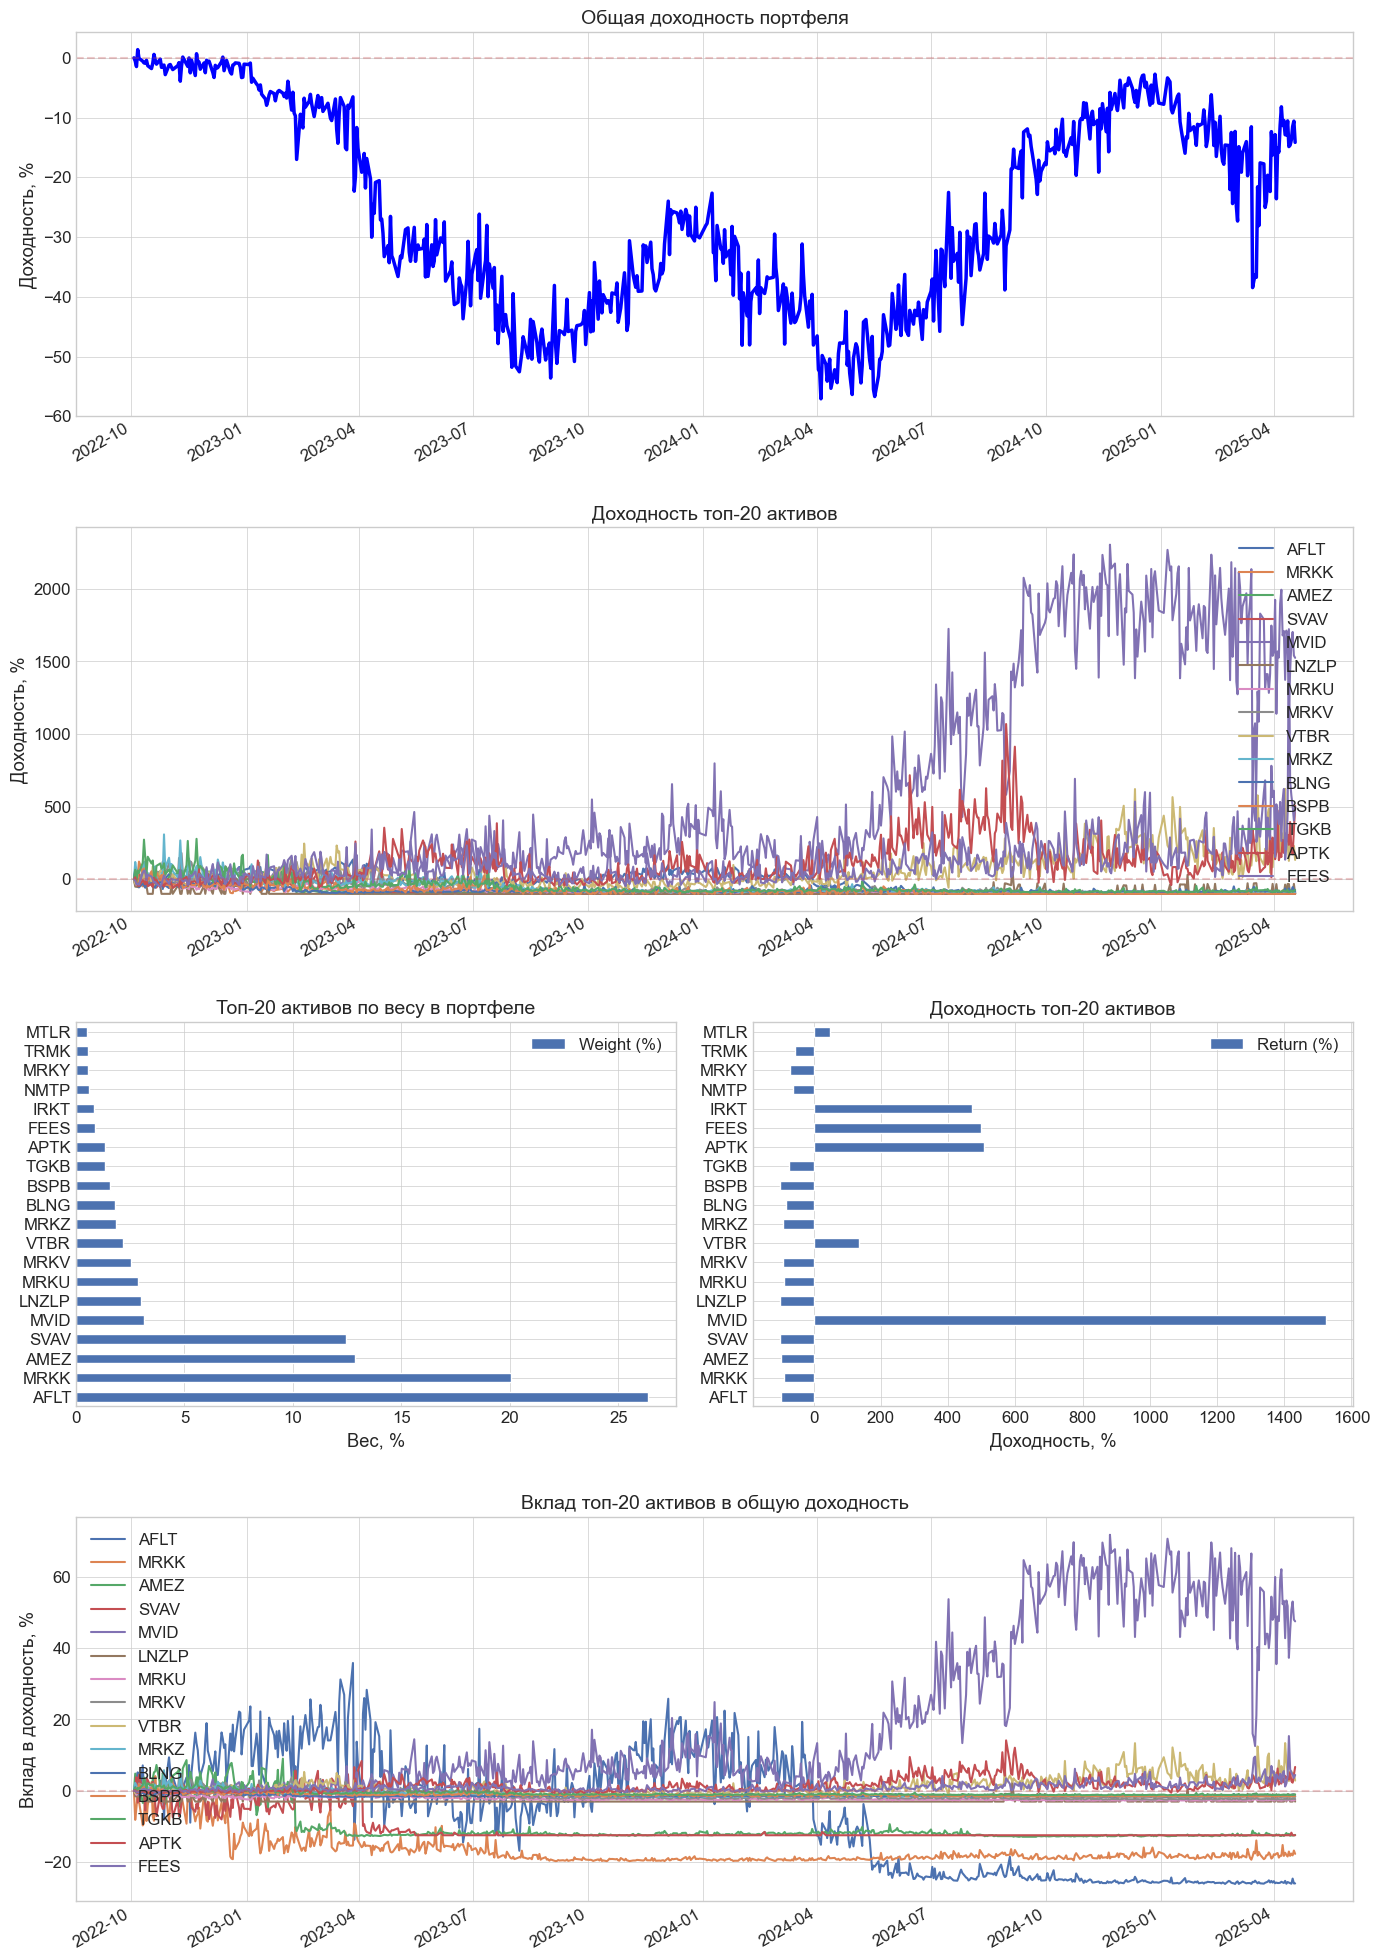

In [26]:
summary=calculate_portfolio_performance(shares_discrete.loc['2022-10-01':][variance_filter],prices.loc['2022-10-01':][variance_filter],top_n_assets=15)
fig=visualize_portfolio_performance(summary)